### Testing space for uMux model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from uMux_modeling.include.model import *

In [2]:

loaded_data = np.loadtxt('NIST_full_s21.txt', dtype=complex)

freqs_loaded = np.real(loaded_data[:, 0])
s21_loaded = loaded_data[:, 1]
s21_db_loaded = np.abs(s21_loaded) 
s21_phase = np.angle(s21_loaded)
s21_logMag = 20*np.log10(s21_db_loaded)
s21_logMag = s21_logMag-np.max(s21_logMag)



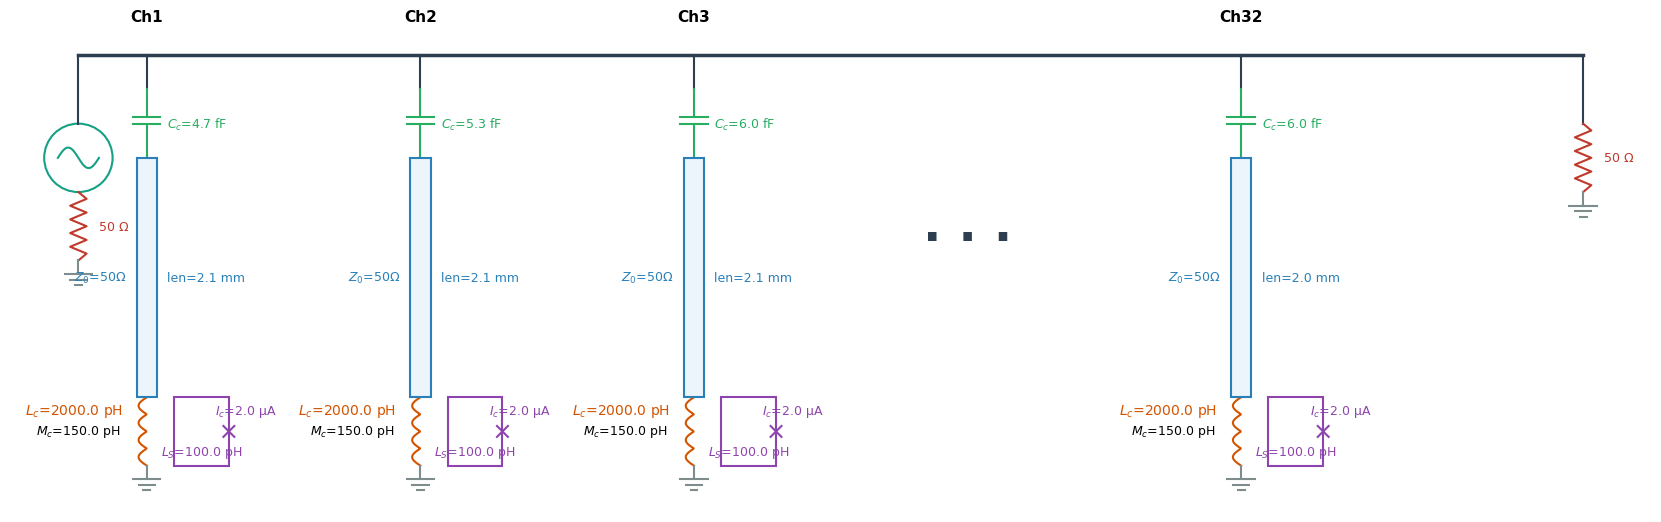

In [5]:
loaded_params = np.loadtxt('NIST_full_params.txt', dtype=float)

VNA = VNA_Simulator(z0=50)

Phi0 = 2.067e-15
squid1 = SQUID(I_c=2e-6, L_loop=100e-12, phi_ext=3 * Phi0)
ind1 = Inductor(2e-9)
tuned_L1 = ScreenedInductor(primary_inductor=ind1, screening_device=squid1, M=150e-12)

count= 1
for params in loaded_params:
    length, Cc_val, Qi_val = extract_physical_params(params, tuned_L1)
    cap1 = Capacitor(C=Cc_val)
    phys_res = Resonator(length=length, load=tuned_L1, v_p=1.15e8, Qi=Qi_val)

    channel1 = Channel(name="Ch"+str(count))
    count+=1
    channel1.add(cap1)
    channel1.add(phys_res)
    VNA.add(channel1, 'shunt')
    
VNA.draw_schematic(use_color=True)
    
    

/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


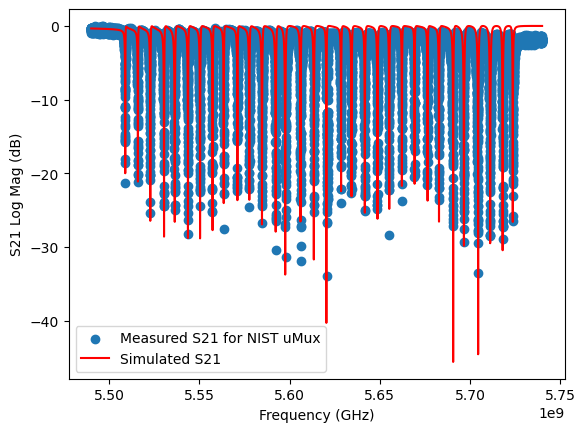

In [4]:
S = VNA.get_s_matrix(freqs_loaded)

plt.scatter(freqs_loaded, s21_logMag, label = "Measured S21 for NIST uMux")
plt.plot(freqs_loaded, 20*np.log10(S[1,0]), color = 'r', label = "Simulated S21")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.legend()
plt.show()

# plt.scatter(freqs_loaded, s21_phase)
# plt.plot(freqs_loaded, np.angle(S[1,0]), color = 'r')
# plt.show()